<a href="https://colab.research.google.com/github/hminh1012/MTCNN-vs-Haar-Cascade/blob/main/MTCNN_vs_Haarcascade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
olgabelitskaya_yale_face_database_path = kagglehub.dataset_download('olgabelitskaya/yale-face-database')

print('Data source import complete.')


Using Colab cache for faster access to the 'yale-face-database' dataset.
Data source import complete.


In [9]:
#import libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from PIL import Image
%matplotlib inline



## Yalefaces dataset  was created locally using yale-faces-database dataset and the commented cells below.
## The exact structure of yalefaces dataset is required in order to use split-folders library

In [10]:
def rename_files(path):
    for filename in os.listdir(path):
        if filename!='Readme.txt' and  not filename.endswith('.jpg') :

            dst = filename + '.jpg'
            src = os.path.join(path, filename)
            dst = os.path.join(path, dst)
            os.rename(src, dst)





In [11]:
#for each  subject in the data folder create a new folder in the data folder
#and move all the images of that subject to that folder
def split_files(path):
    for filename in os.listdir(path):
        if  filename.endswith('.jpg') :
         #split the name of the file to get the subject name
            subject_name=filename.split('.')[0]
        #create a new folder for each subject
            if not os.path.exists(os.path.join(path,subject_name)):
                os.makedirs(os.path.join(path,subject_name))
        #move the file to the new folder
            src = os.path.join(path, filename)
            dst = os.path.join(path, subject_name, filename)
            os.rename(src, dst)


# The dataset is downloaded to the default Kaggle data directory in Colab
YaleFacesPath="/kaggle/input/yale-face-database/data"
if not os.path.exists(os.path.join(YaleFacesPath,'subject01')):
       split_files(YaleFacesPath)

In [12]:
!pip install split-folders

In [13]:
import splitfolders
import os



In [14]:
import shutil

# Define the source and destination paths
source_path = "/kaggle/input/yale-face-database/data"
destination_path = "/content/yale-face-database"

# Copy the data to a writable directory
if not os.path.exists(destination_path):
    shutil.copytree(source_path, destination_path)
    print(f"Data copied from {source_path} to {destination_path}")
else:
    print(f"Destination directory {destination_path} already exists. Skipping copy.")

Data copied from /kaggle/input/yale-face-database/data to /content/yale-face-database


In [15]:
def rename_files(path):
    for filename in os.listdir(path):
        if filename!='Readme.txt' and  not filename.endswith('.jpg') :

            dst = filename + '.jpg'
            src = os.path.join(path, filename)
            dst = os.path.join(path, dst)
            os.rename(src, dst)



# Rename files in the writable directory
YaleFacesPath="/content/yale-face-database"
rename_files(YaleFacesPath)

In [16]:
#for each  subject in the data folder create a new folder in the data folder
#and move all the images of that subject to that folder
def split_files(path):
    for filename in os.listdir(path):
        if  filename.endswith('.jpg') :
         #split the name of the file to get the subject name
            subject_name=filename.split('.')[0]
        #create a new folder for each subject
            if not os.path.exists(os.path.join(path,subject_name)):
                os.makedirs(os.path.join(path,subject_name))
        #move the file to the new folder
            src = os.path.join(path, filename)
            dst = os.path.join(path, subject_name, filename)
            os.rename(src, dst)


# Split files in the writable directory
YaleFacesPath="/content/yale-face-database"
if not os.path.exists(os.path.join(YaleFacesPath,'subject01')):
       split_files(YaleFacesPath)

In [17]:
import splitfolders
import os

# The dataset is now in the writable directory
YaleFacesPath="/content/yale-face-database"
#if output folder already exists delete it
if not os.path.exists("./output"):

    splitfolders.ratio(YaleFacesPath, seed=1337, ratio=(.8, .1, .1))

Copying files: 165 files [00:00, 3464.35 files/s]


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


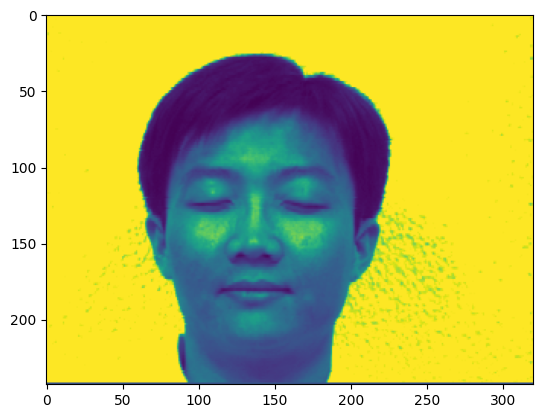

In [19]:
img=plt.imread('./output/test/subject14/subject14.sleepy.jpg')
plt.imshow(img)
plt.show()

In [20]:
#use train and val folders to train the model
train_path=os.path.join("./output",'train')
val_path=os.path.join("./output",'val')
test_path=os.path.join("./output",'test')


In [21]:
def split_data(path):
    images=[]
    labels=[]
    for filename in os.listdir(path):
        if filename.endswith('.jpg'):
            image=plt.imread(os.path.join(path,filename))
            images.append(image)
            labels.append(filename.split('.')[0])
    return images,labels

In [22]:
#for each subject in the train folder split the images and labels
#look in each subfolder and get the images and labels

def data_split(path):

    images=[]
    labels=[]
    for subject in os.listdir(path):
        if os.path.isdir(os.path.join(path,subject)):
            subject_path=os.path.join(path,subject)
            subject_images,subject_labels=split_data(subject_path)
            images.extend(subject_images)
            labels.extend(subject_labels)
    return images,labels

In [23]:
X_train,y_train=data_split(train_path)
X_val,y_val=data_split(val_path)
X_test,y_test=data_split(test_path)


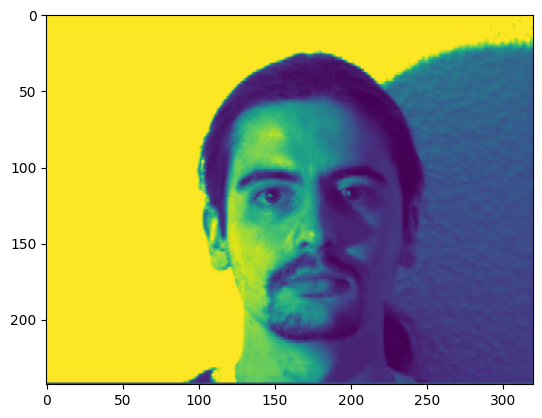

In [24]:
#show the first image of the train folder
plt.imshow(X_train[0])
plt.show()


In [25]:
#get unique values of a list
labels=[]
for i in range(len(y_train)):
    if y_train[i] not in labels:
        labels.append(y_train[i])

print(labels)

['subject09', 'subject06', 'subject05', 'subject15', 'subject03', 'subject01', 'subject10', 'subject12', 'subject08', 'subject02', 'subject11', 'subject14', 'subject13', 'subject04', 'subject07']


In [26]:
print(np.array(X_train).shape)
print(np.array(y_train).shape)


(120, 243, 320)
(120,)


# Face detection with MTCNN


In [27]:
!pip install mtcnn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.3 MB/s eta 0:00:00


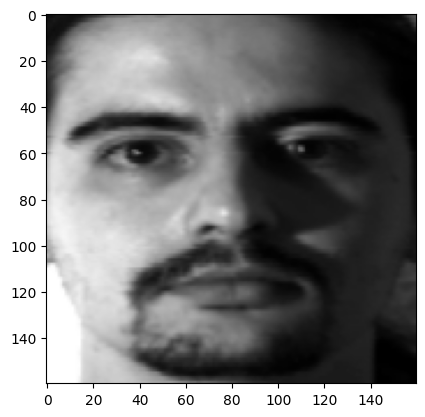

In [28]:
#import mtcnn
from mtcnn.mtcnn import MTCNN


#create a detector
detector = MTCNN()
#detect face in a single image
def detect_face(image):
    #convert the image to RGB
    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    image=np.array(image)
    #detect faces in the image
    result=detector.detect_faces(image)
    #if no face is detected return None, None
    if len(result)==0:
        return None, None
    #extract the bounding box of the face
    x1,y1,width,height=result[0]['box']
    #extract the face
    face=image[y1:y1+height,x1:x1+width]
    #resize the face to a fixed size
    face=cv2.resize(face,(160,160))
    return face, (x1, y1, width, height)


#get  faces  and resize the images to a fixed size
def get_faces(images):
    faces = []
    boxes = []
    for image in images:
        face, box = detect_face(image)
        if face is not None:
            faces.append(face)
            boxes.append(box)
        else:
            # Append None for cases where no face is detected
            faces.append(None)
            boxes.append(None)
    return (faces, boxes) # Explicitly return a tuple



face, box = detect_face(X_train[0])
if face is not None:
    plt.imshow(face)
    plt.show()

In [35]:
# Get faces and boxes for train, validation, and test sets using MTCNN
X_train_data_mtcnn, X_train_boxes_mtcnn = get_faces(X_train)
X_val_data_mtcnn, X_val_boxes_mtcnn = get_faces(X_val)
X_test_data_mtcnn, X_test_boxes_mtcnn = get_faces(X_test)



# Calculate IoU for MTCNN (assuming you have ground truth boxes)
# Note: To calculate meaningful IoU, you would need ground truth bounding boxes for each image.
# Since ground truth boxes are not available in this notebook, we will skip IoU calculation for now.
# If you have ground truth boxes, you can add the code here to calculate IoU.

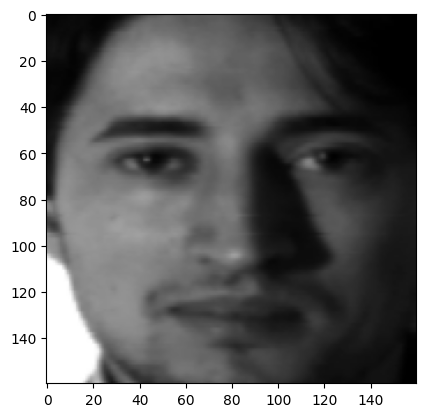

In [36]:
#show a random image from the train folder
plt.imshow(X_train_data_mtcnn[np.random.randint(0,len(X_train))])

In [38]:
#prepare the data for the model
X_train_data=np.array(X_train_data_mtcnn)
X_val_data=np.array(X_val_data_mtcnn)
X_test_data=np.array(X_test_data_mtcnn)


#convert the labels tp numeric values
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
y_train=label_encoder.fit_transform(y_train)
y_val=label_encoder.fit_transform(y_val)
y_test=label_encoder.fit_transform(y_test)

#show the shape of the data
print(X_train_data.shape)
print(X_val_data.shape)
print(X_test_data.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)


(120, 160, 160, 3)
(15, 160, 160, 3)
(30, 160, 160, 3)
(120,)
(15,)
(30,)


In [39]:
#tensors
import tensorflow as tf

X_train_tensor=tf.convert_to_tensor(X_train_data,dtype=tf.float32)
X_val_tensor=tf.convert_to_tensor(X_val_data,dtype=tf.float32)
X_test_tensor=tf.convert_to_tensor(X_test_data,dtype=tf.float32)

In [40]:
#IMAGE DATA GENERATOR
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#create the image data generator
image_data_generator=ImageDataGenerator(
    rescale=1./255,
    fill_mode='nearest'

)
train_image_generator=image_data_generator.flow(X_train_tensor,y_train,batch_size=32)
val_image_generator=image_data_generator.flow(X_val_tensor,y_val,batch_size=32)
test_image_generator=image_data_generator.flow(X_test_tensor,y_test,batch_size=32)


In [41]:
#sequential model
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras import regularizers


In [48]:
#create the model
model=Sequential()
#add convolutional layer
model.add(Conv2D(filters=32,kernel_size=(3,3),padding='Same',activation='relu',kernel_regularizer=regularizers.l2(0.001),input_shape=(160,160,3))) #3 on mtcnn 1 on cv2
# #model add dropout
model.add(Dropout(0.2))
#add max pooling layer
model.add(MaxPooling2D(pool_size=(2,2)))
#add convolutional layer
model.add(Conv2D(filters=64,kernel_size=(3,3),padding='Same',activation='relu',kernel_regularizer=regularizers.l2(0.001)))
# #model add dropout
model.add(Dropout(0.2))
#add max pooling layer
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
#add convolutional layer
model.add(Conv2D(filters=96,kernel_size=(3,3),padding='Same',activation='relu',kernel_regularizer=regularizers.l2(0.001)))
#model add dropout
model.add(Dropout(0.2))
#add max pooling layer
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
#add convolutional layer
model.add(Conv2D(filters=128,kernel_size=(3,3),padding='Same',activation='relu',kernel_regularizer=regularizers.l2(0.001)))

# model add dropout
model.add(Dropout(0.2))

#add max pooling layer
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Dropout(0.5))

#flatten the data
model.add(Flatten())
#add fully connected layer
model.add(Dense(512,activation='relu'))

#model add dropout
model.add(Dropout(0.5))
model.add(Dense(15,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:

epochs=100

# early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping=EarlyStopping(monitor ="val_loss",
                                        mode ="min", patience = 5,
                                        restore_best_weights = True)


from keras.callbacks import ReduceLROnPlateau
red_lr=ReduceLROnPlateau(monitor='val_accuracy',patience=3,verbose=1,factor=0.1)

In [50]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [51]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 40, 40, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 40, 40, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 20, 20, 128)    │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,747,311 (25.74 MB)

 Trainable params: 6,747,311 (25.74 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
History=model.fit(train_image_generator,epochs=epochs,validation_data=val_image_generator,callbacks=[early_stopping,red_lr])


Epoch 1/100
3/4 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0472 - loss: 3.0842 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.0483 - loss: 3.0757 - val_accuracy: 0.3333 - val_loss: 2.8965 - learning_rate: 0.0010
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.0843 - loss: 2.8787 - val_accuracy: 0.2667 - val_loss: 2.8537 - learning_rate: 0.0010
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1890 - loss: 2.8116 - val_accuracy: 0.5333 - val_loss: 2.7297 - learning_rate: 0.0010
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3083 - loss: 2.5208 - val_accuracy: 0.8000 - val_loss: 2.2522 - learning_rate: 0.0010
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3779 - loss: 2.0864 - val_accuracy: 0.8667 - val_loss: 1.9424 - learning_rate: 0.0010
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5479 - loss: 1.6288 - val_accuracy: 0.9333 - val_loss: 1.3324 - learning_rate: 0.0010
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7073 - loss: 1.1742 - val_accuracy: 1.0000 - val_

## Evalutation of model train with MTCNN face embeddings

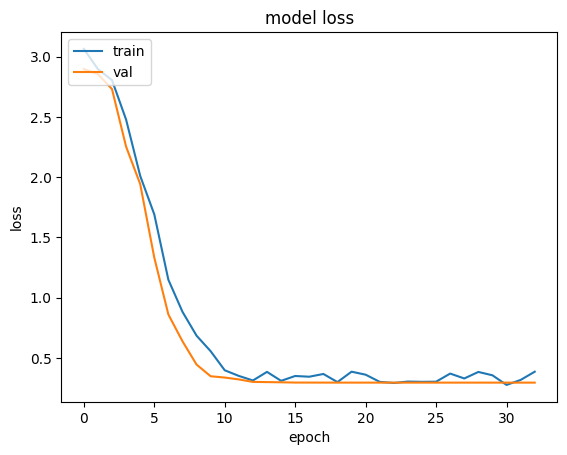

In [53]:
#plot the training and validation loss
plt.plot(History.history['loss'])
plt.plot(History.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','val'],loc='upper left')
plt.show()


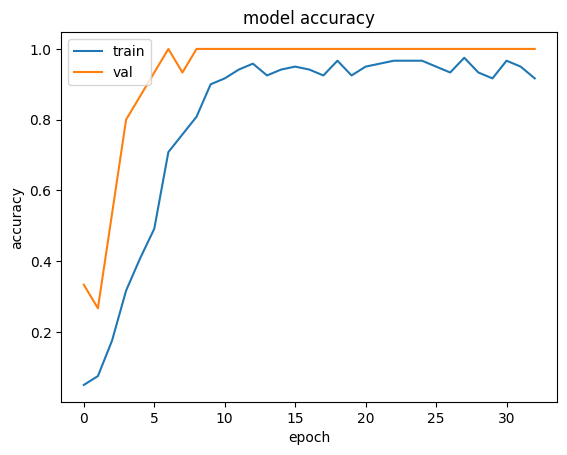

In [54]:
#plot the training and validation accuracy
plt.plot(History.history['accuracy'])
plt.plot(History.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','val'],loc='upper left')
plt.show()


In [55]:
#evaluate the model
score=model.evaluate(X_test_tensor,y_test,verbose=0)
print('Test loss:',score[0])
print('Test accuracy:',score[1])
model.layers
#model parameters
model.summary()
#model output shape
model.output_shape


Test loss: 4.333516597747803
Test accuracy: 0.9666666388511658


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 40, 40, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 40, 40, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 20, 20, 128)    │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,241,935 (77.22 MB)

 Trainable params: 6,747,311 (25.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,494,624 (51.48 MB)

(None, 15)

## Model prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step


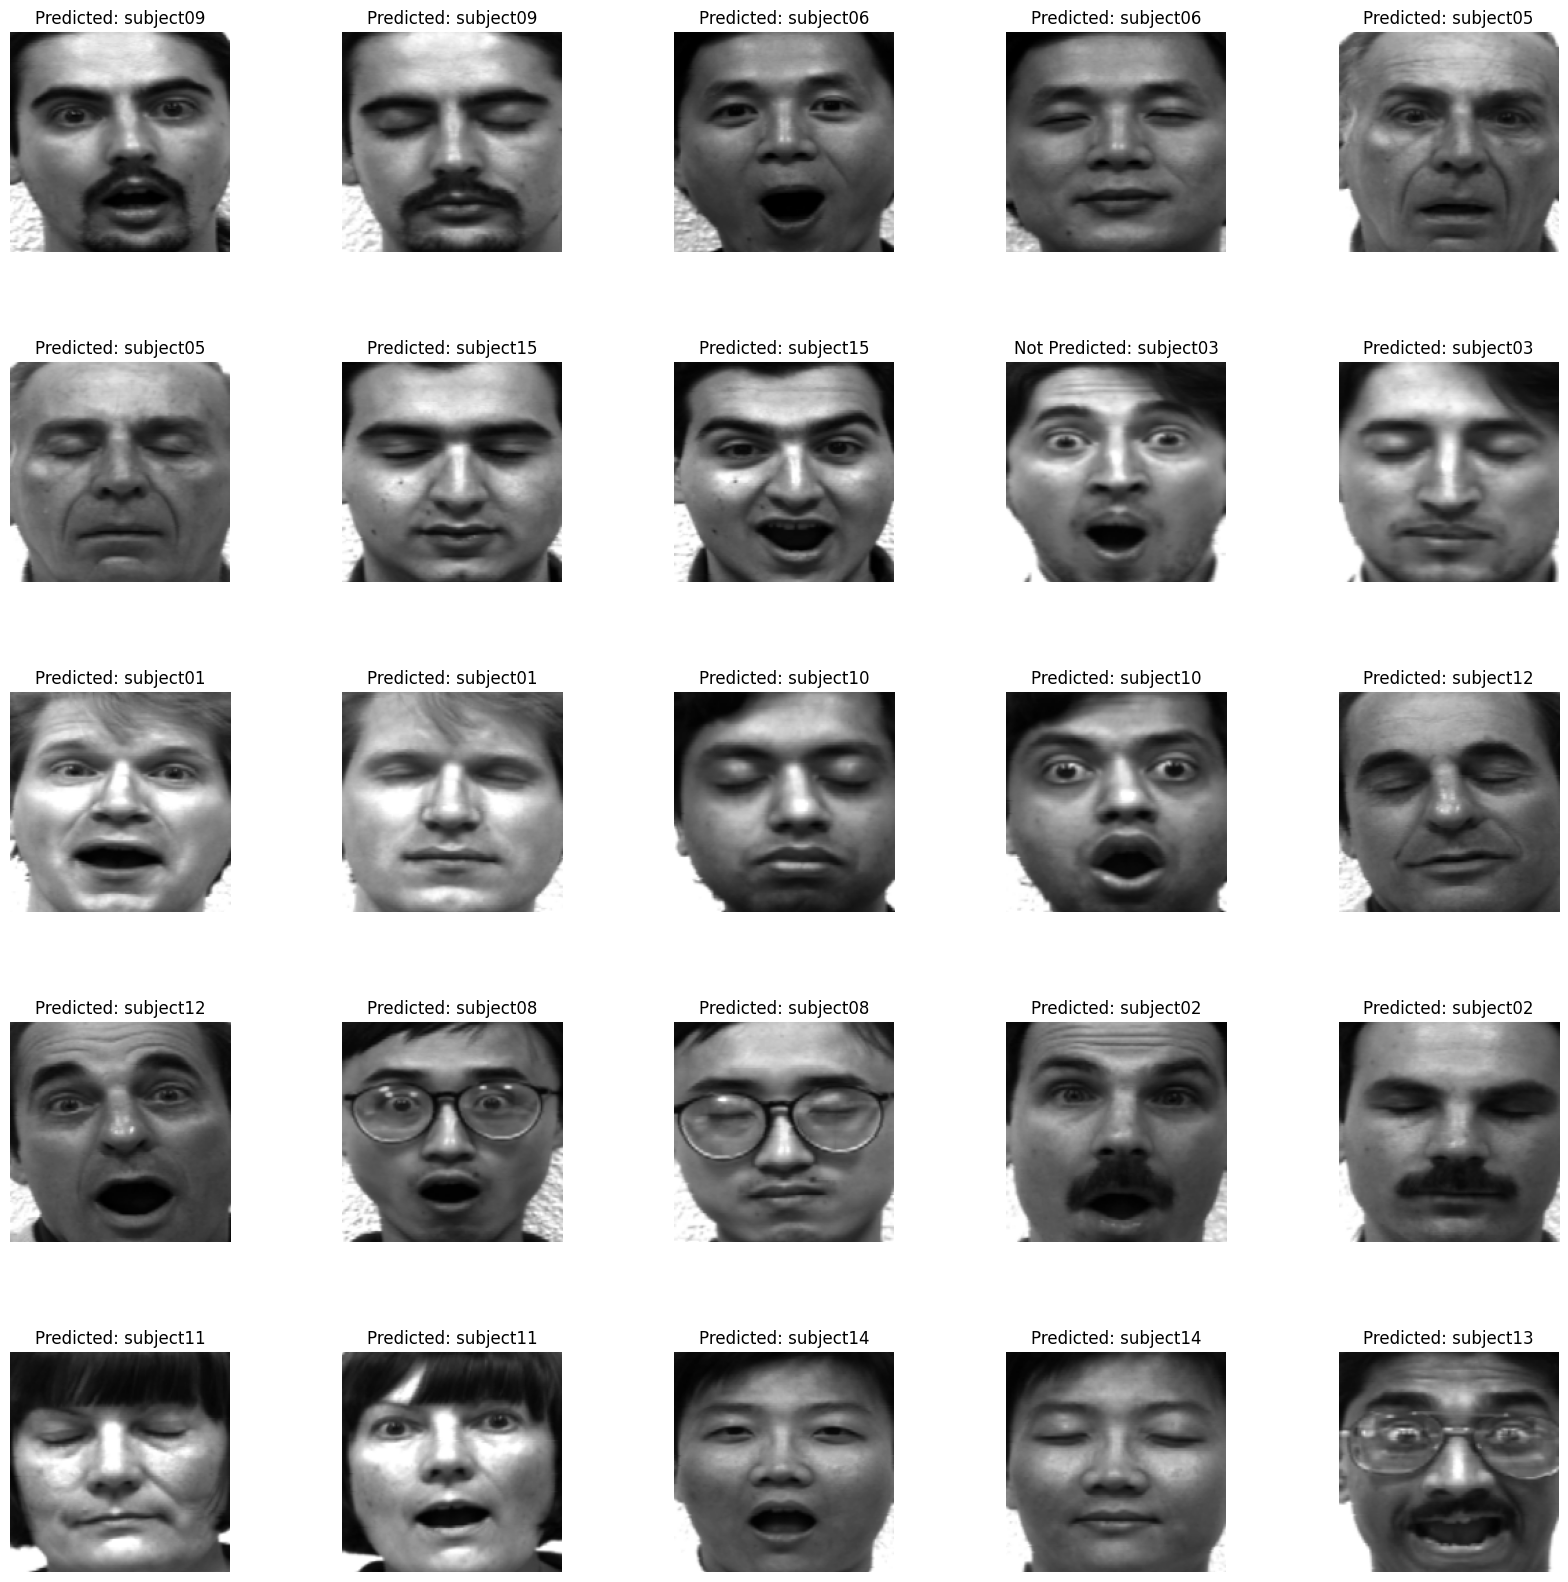

In [56]:
#current preditciton
subjects=['subject01','subject02','subject03','subject04','subject05','subject06','subject07','subject08','subject09','subject10','subject11','subject12','subject13','subject14','subject15']
currpred=model.predict(X_test_tensor)

fig,axes=plt.subplots(5,5,figsize=(20,20))
fig.subplots_adjust(hspace=0.5,wspace=0.5)
#iterate over the 5x5 grid of subplots
for i,ax in enumerate(axes.flat):
    #plot image
    ax.imshow(X_test_data[i])
    #get label from one-hot vector
    label=np.argmax(currpred[i])
    #get correct answer
    answer=y_test[i]
    #label the image with the answer
    if answer==label:
       ax.set_title("Predicted: "+subjects[answer])
    else:
       ax.set_title("Not Predicted: "+subjects[answer])
    ax.set_axis_off()
plt.show()







In [57]:
#save new model
if(score[1]>=0.966 and score[0]<=20):
    model.save('mtcnnmodel.h5')
    print('model saved')
else:
    model.save('mtcnnmodel.h5')
    print('model not saved')



model saved


In [58]:
from sklearn.metrics import classification_report

# Calculate Precision, Recall, and F1 Score for the Haar Cascade model
print("--- Evaluation for MTCNN Model ---")
print(classification_report(y_test, np.argmax(currpred, axis=1), target_names=subjects))

--- Evaluation for MTCNN Model ---
              precision    recall  f1-score   support

   subject01       1.00      1.00      1.00         2
   subject02       1.00      1.00      1.00         2
   subject03       1.00      0.50      0.67         2
   subject04       1.00      1.00      1.00         2
   subject05       1.00      1.00      1.00         2
   subject06       1.00      1.00      1.00         2
   subject07       1.00      1.00      1.00         2
   subject08       1.00      1.00      1.00         2
   subject09       1.00      1.00      1.00         2
   subject10       1.00      1.00      1.00         2
   subject11       1.00      1.00      1.00         2
   subject12       1.00      1.00      1.00         2
   subject13       1.00      1.00      1.00         2
   subject14       0.67      1.00      0.80         2
   subject15       1.00      1.00      1.00         2

    accuracy                           0.97        30
   macro avg       0.98      0.97      0.96  

In [59]:
def calculate_iou(box1, box2):
    """
    Calculates the Intersection over Union (IoU) of two bounding boxes.

    Args:
        box1: A tuple representing the first bounding box (x1, y1, w1, h1).
        box2: A tuple representing the second bounding box (x2, y2, w2, h2).

    Returns:
        The IoU of the two bounding boxes.
    """
    # Convert width and height to x2 and y2
    box1 = [box1[0], box1[1], box1[0] + box1[2], box1[1] + box1[3]]
    box2 = [box2[0], box2[1], box2[0] + box2[2], box2[1] + box2[3]]

    # Determine the coordinates of the intersection rectangle
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    # Compute the area of intersection rectangle
    intersection_area = max(0, x_right - x_left) * max(0, y_bottom - y_top)

    # Compute the area of both the prediction and ground-truth rectangles
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Compute the intersection over union by dividing the intersection area by the sum of prediction + ground-truth areas - the intersection area
    iou = intersection_area / (box1_area + box2_area - intersection_area)

    return iou

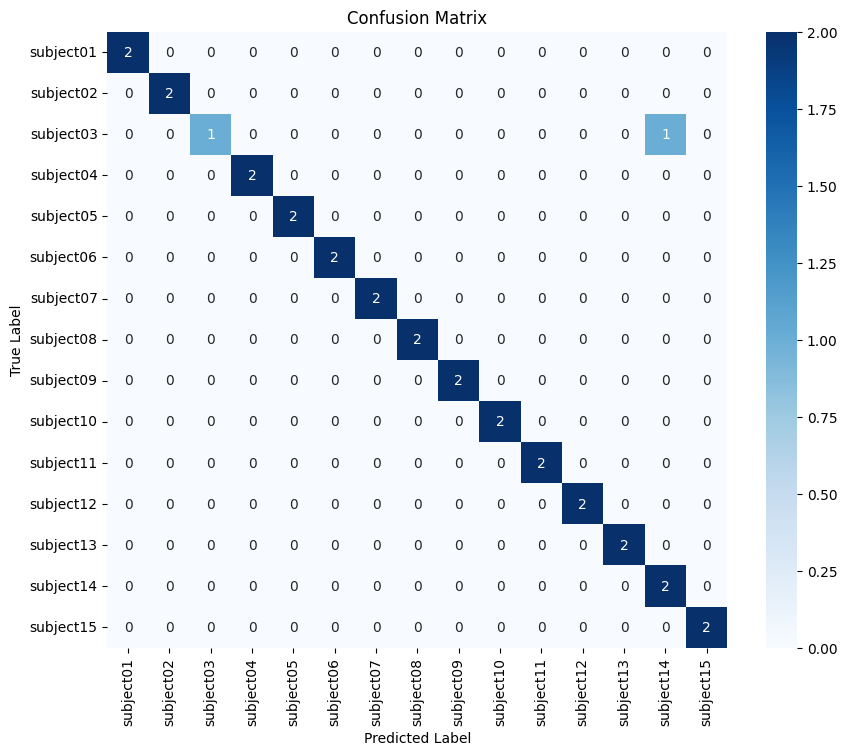

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, np.argmax(currpred, axis=1))

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=subjects, yticklabels=subjects)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Face detection with Haar Cascade Classifier



In [61]:
#detect faces in the images
def detect_faces(image):
 #use PIL
    image=Image.fromarray(image)
    image=np.array(image)

    # Find the path to the Haar Cascade XML file
    haar_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'

    #detect faces
    detector=cv2.CascadeClassifier(haar_cascade_path)
    faces=detector.detectMultiScale(  image,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(20, 20)
    )
    return faces

#resize the faces
def get_face(image):
    faces=detect_faces(image)
    if len(faces)>0:
        x,y,w,h=faces[0]
        face_image=image[y:y+h,x:x+w]
        #cut the face from the image

        face_image=cv2.resize(face_image,(160,160))

        return face_image, (x, y, w, h)
    else:
        return None, None

def get_faces(images):
    faces = []
    boxes = []
    for image in images:
        face, box = get_face(image)
        if face is not None:
            faces.append(face)
            boxes.append(box)
        else:
            faces.append(None)
            boxes.append(None)
    return faces, boxes

In [62]:
X_train_data_haar, X_train_boxes_haar = get_faces(X_train)
X_val_data_haar, X_val_boxes_haar = get_faces(X_val)
X_test_data_haar, X_test_boxes_haar = get_faces(X_test)

# Calculate IoU for Haar Cascade (assuming you have ground truth boxes)
# Note: To calculate meaningful IoU, you would need ground truth bounding boxes for each image.
# Since ground truth boxes are not available in this notebook, we will skip IoU calculation for now.
# If you have ground truth boxes, you can add the code here to calculate IoU.

In [63]:
import cv2
import os

# Find the path to the Haar Cascade XML file
haar_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'

# Check if the file exists
if os.path.exists(haar_cascade_path):
    print(f"Haar Cascade XML file found at: {haar_cascade_path}")
else:
    print(f"Haar Cascade XML file not found at: {haar_cascade_path}")

Haar Cascade XML file found at: /usr/local/lib/python3.12/dist-packages/cv2/data/haarcascade_frontalface_default.xml


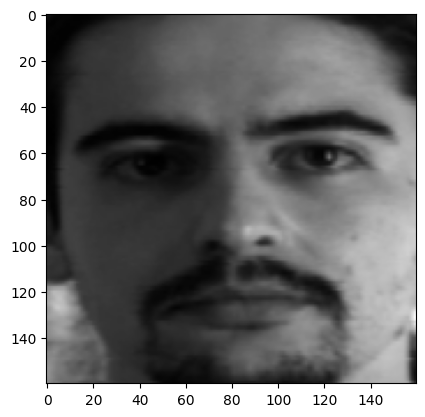

In [64]:
plt.imshow(X_train_data[np.random.randint(0,len(X_train))])

In [67]:
#prepare the data for the model
X_train_data=np.array(X_train_data_haar)
X_val_data=np.array(X_val_data_haar)
X_test_data=np.array(X_test_data_haar)

# # convert images shape to (samples,width,height,channels) if not fed in mtcnn
# X_train_data=np.reshape(X_train_data,(X_train_data.shape[0],X_train_data.shape[1],X_train_data.shape[2],1))
# X_val_data=np.reshape(X_val_data,(X_val_data.shape[0],X_val_data.shape[1],X_val_data.shape[2],1))
# X_test_data=np.reshape(X_test_data,(X_test_data.shape[0],X_test_data.shape[1],X_test_data.shape[2],1))

#convert the labels tp numeric values
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
y_train=label_encoder.fit_transform(y_train)
y_val=label_encoder.fit_transform(y_val)
y_test=label_encoder.fit_transform(y_test)

#show the shape of the data
print(X_train_data.shape)
print(X_val_data.shape)
print(X_test_data.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(120, 160, 160)
(15, 160, 160)
(30, 160, 160)
(120,)
(15,)
(30,)


In [68]:


X_train_tensor=tf.convert_to_tensor(X_train_data,dtype=tf.float32)
X_val_tensor=tf.convert_to_tensor(X_val_data,dtype=tf.float32)
X_test_tensor=tf.convert_to_tensor(X_test_data,dtype=tf.float32)

In [70]:
#IMAGE DATA GENERATOR
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#create the image data generator
image_data_generator=ImageDataGenerator(
    rescale=1./255,
    fill_mode='nearest'

)

# Reshape data to add channel dimension for grayscale images (Haar Cascade)
X_train_data = np.reshape(X_train_data, (X_train_data.shape[0], X_train_data.shape[1], X_train_data.shape[2], 1))
X_val_data = np.reshape(X_val_data, (X_val_data.shape[0], X_val_data.shape[1], X_val_data.shape[2], 1))
X_test_data = np.reshape(X_test_data, (X_test_data.shape[0], X_test_data.shape[1], X_test_data.shape[2], 1))

train_image_generator=image_data_generator.flow(X_train_data,y_train,batch_size=32)
val_image_generator=image_data_generator.flow(X_val_data,y_val,batch_size=32)
test_image_generator=image_data_generator.flow(X_test_data,y_test,batch_size=32)

In [71]:
#create the model
model=Sequential()
#add convolutional layer
model.add(Conv2D(filters=32,kernel_size=(3,3),padding='Same',activation='relu',kernel_regularizer=regularizers.l2(0.001),input_shape=(160,160,1))) #3 on mtcnn 1 on cv2
# #model add dropout
model.add(Dropout(0.2))
#add max pooling layer
model.add(MaxPooling2D(pool_size=(2,2)))
#add convolutional layer
model.add(Conv2D(filters=64,kernel_size=(3,3),padding='Same',activation='relu',kernel_regularizer=regularizers.l2(0.001)))
# #model add dropout
model.add(Dropout(0.2))
#add max pooling layer
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
#add convolutional layer
model.add(Conv2D(filters=96,kernel_size=(3,3),padding='Same',activation='relu',kernel_regularizer=regularizers.l2(0.001)))
#model add dropout
model.add(Dropout(0.2))
#add max pooling layer
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
#add convolutional layer
model.add(Conv2D(filters=128,kernel_size=(3,3),padding='Same',activation='relu',kernel_regularizer=regularizers.l2(0.001)))

# model add dropout
model.add(Dropout(0.2))

#add max pooling layer
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Dropout(0.5))

#flatten the data
model.add(Flatten())
#add fully connected layer
model.add(Dense(512,activation='relu'))

#model add dropout
model.add(Dropout(0.5))
model.add(Dense(15,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [73]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 40, 40, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 40, 40, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 20, 20, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 20, 20, 128)    │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,746,735 (25.74 MB)

 Trainable params: 6,746,735 (25.74 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
History2=model.fit(train_image_generator,epochs=epochs,validation_data=val_image_generator,callbacks=[early_stopping,red_lr])

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.0894 - loss: 3.0619 - val_accuracy: 0.0667 - val_loss: 2.9023 - learning_rate: 0.0010
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.0635 - loss: 2.9045 - val_accuracy: 0.2000 - val_loss: 2.8766 - learning_rate: 0.0010
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1646 - loss: 2.8517 - val_accuracy: 0.5333 - val_loss: 2.7854 - learning_rate: 0.0010
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2275 - loss: 2.6651 - val_accuracy: 0.7333 - val_loss: 2.4954 - learning_rate: 0.0010
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2747 - loss: 2.4964 - val_accuracy: 0.8667 - val_loss: 2.1566 - learning_rate: 0.0010
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4811 - loss: 1.8042 - val_accuracy: 0.9333 - val_loss: 1.4060 - learning_rate: 0.0010
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6809 - loss: 1.2892 - val_accuracy: 1.0000 - val_

## HaarCascade Model Evaluation

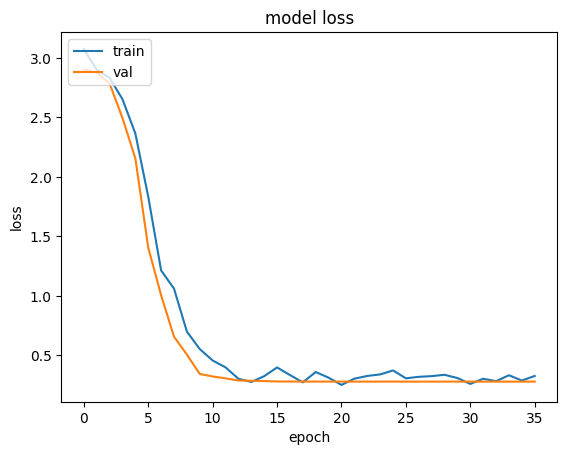

In [75]:
#plot the training and validation loss
plt.plot(History2.history['loss'])
plt.plot(History2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','val'],loc='upper left')
plt.show()

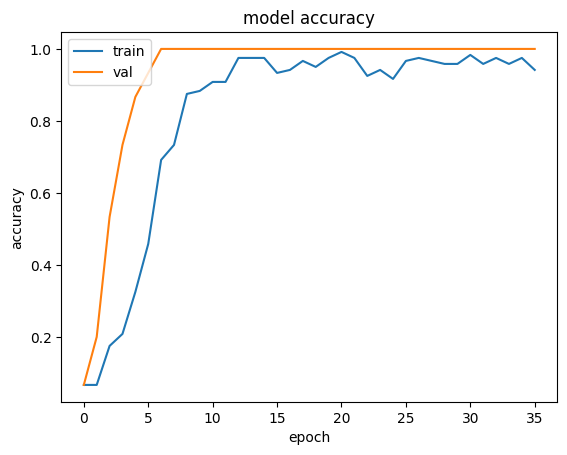

In [76]:
#plot the training and validation accuracy
plt.plot(History2.history['accuracy'])
plt.plot(History2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','val'],loc='upper left')
plt.show()


## Haarcascade model prediction

In [79]:
#evaluate the model
# Reshape X_test_tensor to add channel dimension for grayscale images
X_test_tensor_reshaped = tf.reshape(X_test_tensor, (X_test_tensor.shape[0], X_test_tensor.shape[1], X_test_tensor.shape[2], 1))
score=model.evaluate(X_test_tensor_reshaped,y_test,verbose=0)
print('Test loss:',score[0])
print('Test accuracy:',score[1])
model.layers
#model parameters
model.summary()
#model output shape
model.output_shape

Test loss: 38.70191955566406
Test accuracy: 0.8999999761581421


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 40, 40, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 40, 40, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 20, 20, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 20, 20, 128)    │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,240,207 (77.21 MB)

 Trainable params: 6,746,735 (25.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,493,472 (51.47 MB)

(None, 15)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step


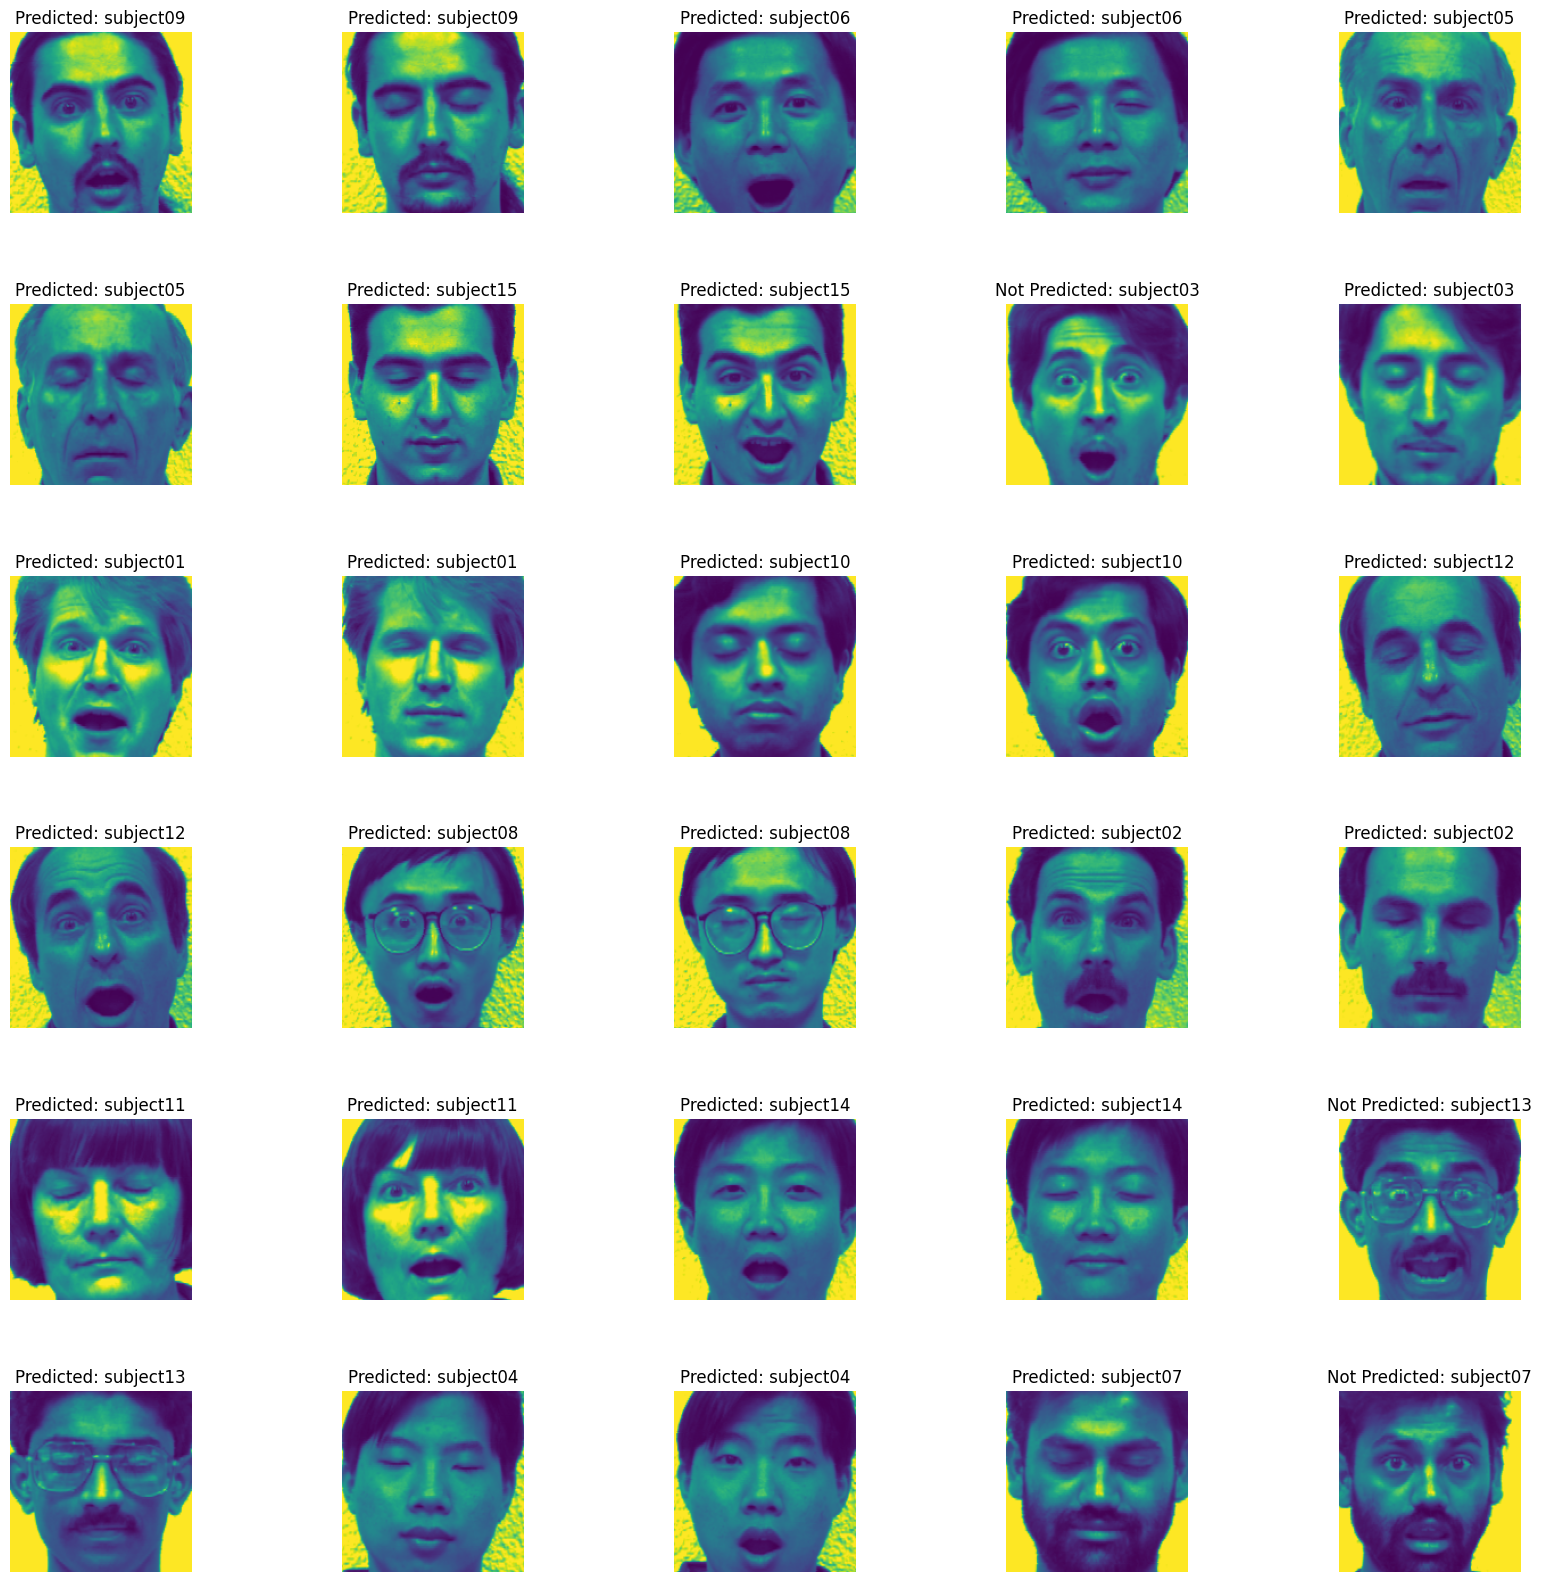

In [80]:
#current preditciton
currpred=model.predict(X_test_tensor)

fig,axes=plt.subplots(6,5,figsize=(20,20))
fig.subplots_adjust(hspace=0.5,wspace=0.5)
#iterate over the 5x5 grid of subplots
for i,ax in enumerate(axes.flat):
    #plot image
    ax.imshow(X_test_data[i])
    #get label from one-hot vector
    label=np.argmax(currpred[i])
    #get correct answer
    answer=y_test[i]
    #label the image with the answer
    if answer==label:
       ax.set_title("Predicted: "+subjects[answer])
    else:
       ax.set_title("Not Predicted: "+subjects[answer])
    ax.set_axis_off()
plt.show()




In [81]:
if(score[1]>=0.899 and score[0]<=33):
    model.save('newhaarmodel.h5')
    print('new model saved')
else:
    model.save('newhaarmodel.h5')
    print('new model not saved')


new model not saved


## Comparison of the two models on loss and accuracy

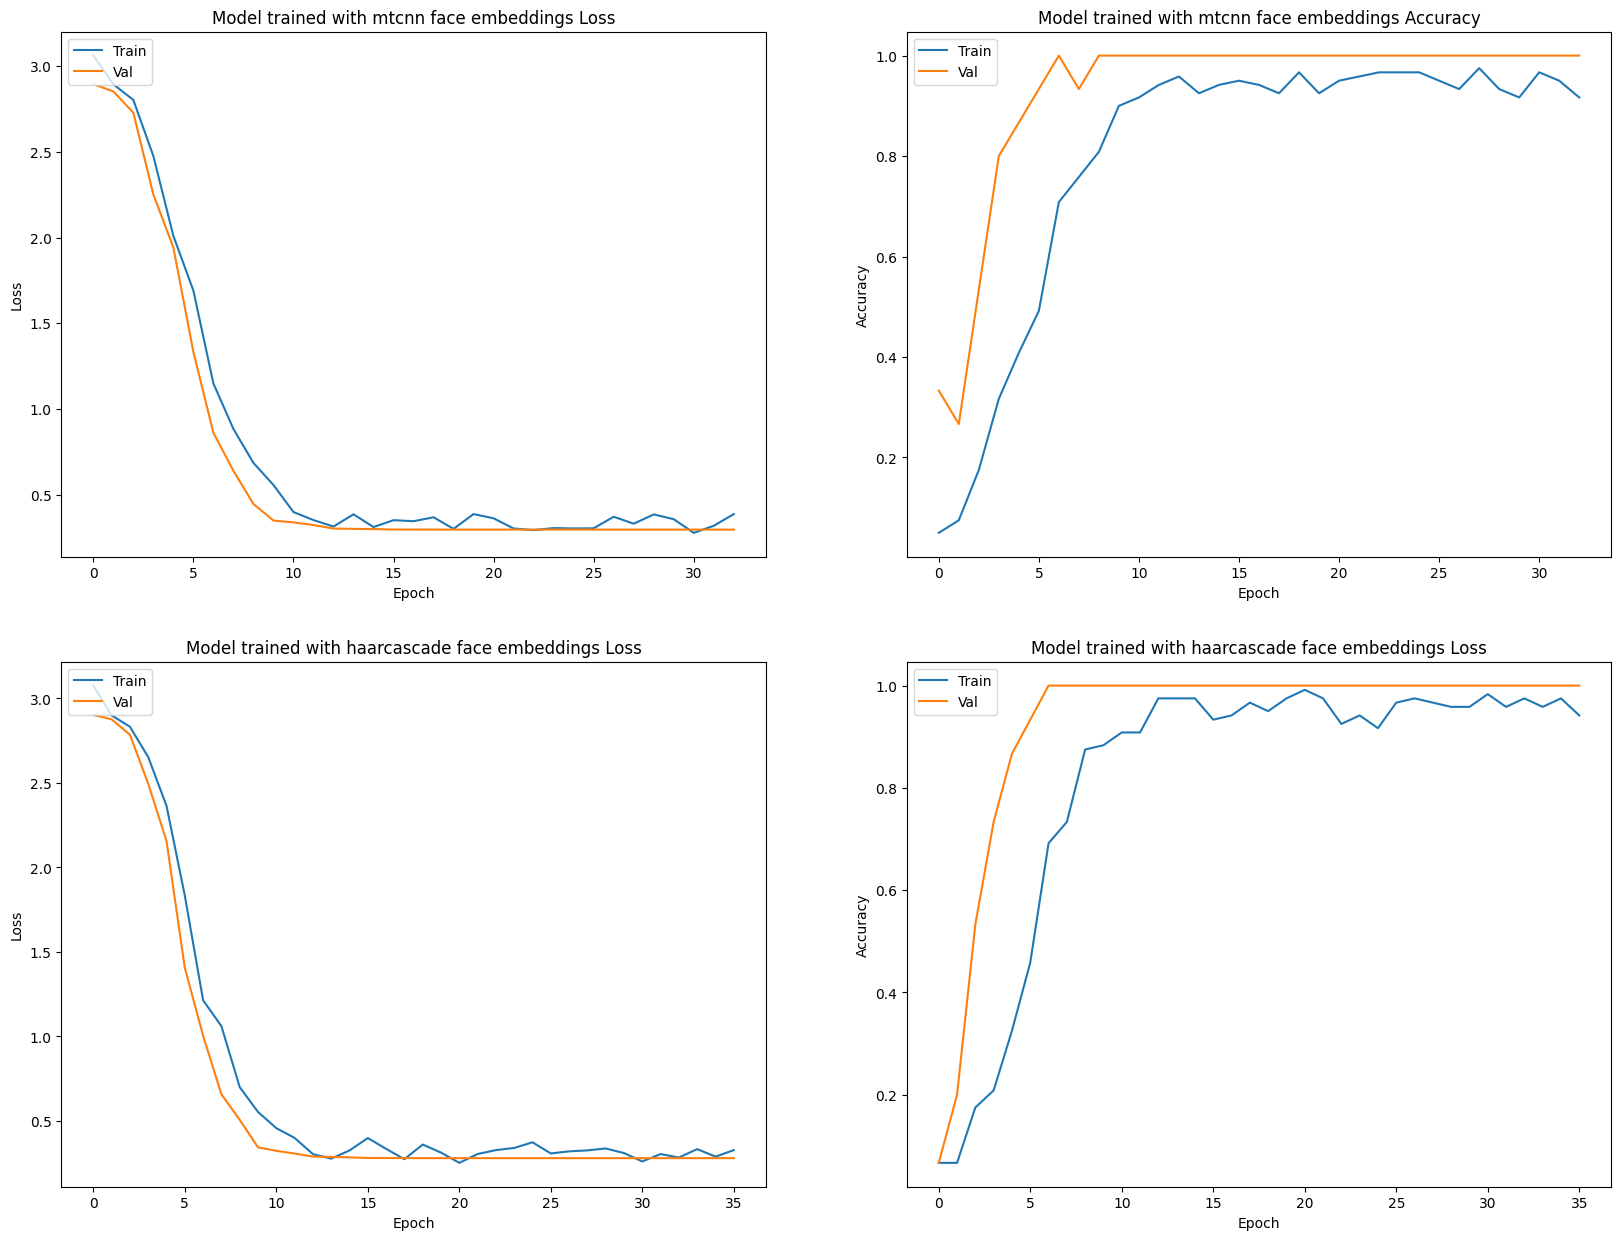

In [82]:
fig, axs = plt.subplots(2, 2)
fig.set_size_inches(20,15)
axs[0,0].plot(History.history['loss'])
axs[0,0].plot(History.history['val_loss'])
axs[0,0].set_title('Model trained with mtcnn face embeddings Loss')
axs[0,0].set_ylabel('Loss')
axs[0,0].set_xlabel('Epoch')
axs[0,0].legend(['Train', 'Val'], loc='upper left')
axs[0,1].plot(History.history['accuracy'])
axs[0,1].plot(History.history['val_accuracy'])
axs[0,1].set_title('Model trained with mtcnn face embeddings Accuracy')
axs[0,1].set_ylabel('Accuracy')
axs[0,1].set_xlabel('Epoch')
axs[0,1].legend(['Train', 'Val'], loc='upper left')
axs[1,0].plot(History2.history['loss'])
axs[1,0].plot(History2.history['val_loss'])
axs[1,0].set_title('Model trained with haarcascade face embeddings Loss')
axs[1,0].set_ylabel('Loss')
axs[1,0].set_xlabel('Epoch')
axs[1,0].legend(['Train', 'Val'], loc='upper left')
axs[1,1].plot(History2.history['accuracy'])
axs[1,1].plot(History2.history['val_accuracy'])
axs[1,1].set_title('Model trained with haarcascade face embeddings Loss')
axs[1,1].set_ylabel('Accuracy')
axs[1,1].set_xlabel('Epoch')
axs[1,1].legend(['Train', 'Val'], loc='upper left')
plt.show()
plt.close()


In [83]:
from sklearn.metrics import classification_report

# Calculate Precision, Recall, and F1 Score for the Haar Cascade model
print("--- Evaluation for Haar Cascade Model ---")
print(classification_report(y_test, np.argmax(currpred, axis=1), target_names=subjects))

--- Evaluation for Haar Cascade Model ---
              precision    recall  f1-score   support

   subject01       1.00      1.00      1.00         2
   subject02       1.00      1.00      1.00         2
   subject03       1.00      0.50      0.67         2
   subject04       0.67      1.00      0.80         2
   subject05       1.00      1.00      1.00         2
   subject06       1.00      1.00      1.00         2
   subject07       1.00      0.50      0.67         2
   subject08       1.00      1.00      1.00         2
   subject09       1.00      1.00      1.00         2
   subject10       1.00      1.00      1.00         2
   subject11       1.00      1.00      1.00         2
   subject12       1.00      1.00      1.00         2
   subject13       0.50      0.50      0.50         2
   subject14       0.67      1.00      0.80         2
   subject15       1.00      1.00      1.00         2

    accuracy                           0.90        30
   macro avg       0.92      0.90     

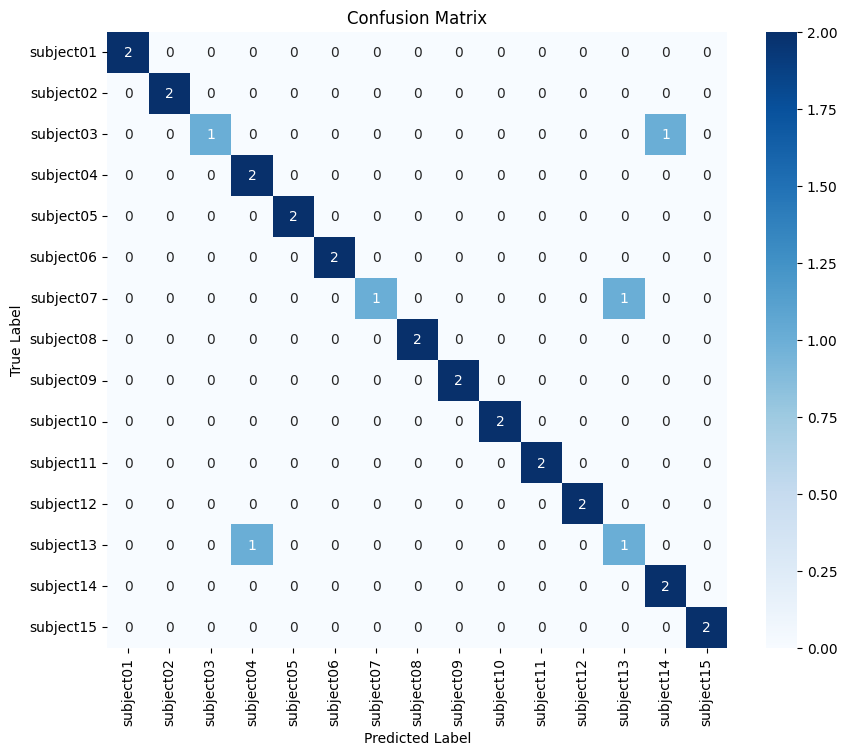

In [84]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, np.argmax(currpred, axis=1))

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=subjects, yticklabels=subjects)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [91]:
import time

# Measure FPS for MTCNN
start_time_mtcnn = time.time()
# Assuming X_test contains the original test images
X_test_data_mtcnn_speed, X_test_boxes_mtcnn_speed = get_faces(X_test)
end_time_mtcnn = time.time()
fps_mtcnn = len(X_test) / (end_time_mtcnn - start_time_mtcnn)
print(f"MTCNN FPS: {fps_mtcnn:.2f}")

# Measure FPS for Haar Cascade
start_time_haar = time.time()
# Assuming X_test contains the original test images
X_test_data_haar_speed, X_test_boxes_haar_speed = get_faces(X_test)
end_time_haar = time.time()
fps_haar = len(X_test) / (end_time_haar - start_time_haar)
print(f"Haar Cascade FPS: {fps_haar:.2f}")

MTCNN FPS: 11.63
Haar Cascade FPS: 17.13
